# Hybrid model for pneumonia detection
## 1 Setup
### 1.1 Installing dependencies

In [1]:
!pip install pennylane scikit-learn numpy scipy matplotlib pandas pennylane-qiskit kagglehub scikit-image seaborn opencv-python torch torchvision pennylane-lightning-gpu optuna tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 11.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.3/911.3 kB 3.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 2.2 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.8 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.7 MB/s eta 0:00:0

### 1.2 Configuration

In [ ]:
from dataclasses import dataclass
import torch
import numpy as np
import random
import os
import math

@dataclass
class ExperimentConfig:
    # Experiment Metadata
    project_name: str = "Hybrid_ResNet50_QNN_Pneumonia"
    seed: int = 6
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Data Paths
    data_root: str = "/"
    output_dir: str = "./results"
    
    # Classical Backbone
    backbone_name: str = "resnet50"  
    feature_dim: int = 2048          # 2048 for ResNet50

    # Preprocessing
    reduction_method: str = "pca"    # 'pca', 'lda' or 'selectkbest'
    target_dims: int = 16            # Dimensionality after reduction
    
    # Quantum Components
    n_qubits: int = math.ceil(math.log2(target_dims))                # Determined by target dimensions
    n_layers: int = 4
    encoding_method: str = "amplitude" # 'amplitude' or 'angle'
    iqp_embedding_layers: int = 2
    ansatz_type: str = "basic" # 'strongly_entangling', 'basic', 'hierarchical_rbs'
    
    
    # Training Hyperparams
    batch_size: int = 8
    learning_rate: float = 0.001
    epochs: int = 50
    patience: int = 10
    min_learning_rate: float = 1e-5
    warmup_epochs: int = 3

    

def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Global seed set to {seed}")

CFG = ExperimentConfig()
seed_everything(CFG.seed)
os.makedirs(CFG.output_dir, exist_ok=True)


🔒 Global seed set to 6


### 1.3 Dataset

In [3]:
import kagglehub

# Download latest version
CFG.data_root = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia") + "/chest_xray/"
print("Path to dataset files:", CFG.data_root)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia/chest_xray/


## 3 Dataloading


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import os

def get_transforms(img_size=224):
    """
    Standard ImageNet normalization. 
    Using standard stats ensures the pre-trained ResNet works as intended.
    """
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_dataloaders(CFG):
    """
    Creates DataLoaders for Train/Test/Val using ImageFolder.
    This replaces manual os.listdir loops.
    """
    loaders = {}
    sets = ['train', 'test', 'val']
    
    print(f"📂 Loading data from: {CFG.data_root}")
    
    for split in sets:
        path = os.path.join(config.data_root, split)
        if not os.path.exists(path):
            print(f"⚠️ Warning: Split '{split}' not found at {path}")
            continue
            
        # ImageFolder automatically handles class labels based on folder names
        dataset = datasets.ImageFolder(root=path, transform=get_transforms())
        
        loaders[split] = DataLoader(
            dataset, 
            batch_size=config.batch_size, 
            shuffle=False, # Important: Keep False to match features with filenames later
            num_workers=2, # Parallel loading
            pin_memory=True
        )
        print(f"   • {split.upper()}: Found {len(dataset)} images")
        
    return loaders

class FeatureExtractor(nn.Module):
    """
    Wraps ResNet50 to output raw features instead of classification scores.
    """
    def __init__(self):
        super().__init__()
        # Load modern V2 weights for better performance
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        self.backbone = models.resnet50(weights=weights)
        
        # Replace the final classification layer (fc) with Identity
        # This allows us to get the 2048 feature vector directly
        self.backbone.fc = nn.Identity()
        self.backbone.eval() # Set to evaluation mode (freezes BatchNorm)
        
    def forward(self, x):
        return self.backbone(x)

def run_feature_extraction(config):
    """
    The Engine: Loads data, passes it through ResNet, and saves features.
    """
    device = torch.device(config.device)
    model = FeatureExtractor().to(device)
    loaders = get_dataloaders(config)
    
    # Create directory for saved features
    save_dir = os.path.join(config.output_dir, "features")
    os.makedirs(save_dir, exist_ok=True)
    
    metadata = []
    
    print(f"\n🚀 Starting extraction with {config.backbone_name} on {device}...")
    
    with torch.no_grad(): # Disable gradient calculation for speed
        for split, loader in loaders.items():
            
            for batch_idx, (images, labels) in enumerate(tqdm(loader, desc=f"Extracting {split}")):
                images = images.to(device)
                
                # Forward pass: Get features (Batch_Size, 2048)
                with torch.amp.autocast(config.device):  # Mixed precision for speed
                    features = model(images)
                
                features = model(images).cpu().numpy()
                # Match features back to original filenames
                # We calculate the global index based on batch size
                start_idx = batch_idx * config.batch_size
                
                for i, feat in enumerate(features):
                    global_idx = start_idx + i
                    # Retrieve path from dataset.samples which is [(path, class_idx), ...]
                    original_path, label_idx = loader.dataset.samples[global_idx]
                    filename = os.path.basename(original_path)
                    classname = loader.dataset.classes[label_idx]
                    
                    # Save individual feature file
                    save_name = f"{split}_{classname}_{filename}.npy"
                    save_path = os.path.join(save_dir, save_name)
                    np.save(save_path, feat)
                    
                    metadata.append({
                        'feature_path': save_path,
                        'label': label_idx, # 0 or 1
                        'classname': classname,
                        'split': split,
                        'original_path': original_path
                    })
    
    # Save metadata CSV for easy loading later
    meta_path = os.path.join(config.output_dir, "metadata.csv")
    pd.DataFrame(metadata).to_csv(meta_path, index=False)
    print(f"✅ Extraction complete. Metadata saved to {meta_path}")
    return meta_path

# Execute the pipeline using our Config
meta_csv_path = run_feature_extraction(CFG)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


📂 Loading data from: /kaggle/input/chest-xray-pneumonia/chest_xray/
   • TRAIN: Found 5216 images
   • TEST: Found 624 images
   • VAL: Found 16 images

🚀 Starting extraction with resnet50 on cuda...


Extracting train:   0%|          | 0/652 [00:00<?, ?it/s]

Extracting test:   0%|          | 0/78 [00:00<?, ?it/s]

Extracting val:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Extraction complete. Metadata saved to ./results/metadata.csv


## 4. Preprocessing

In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split  
import joblib
import os

def load_features(config):
    """
    Loads features from .npy files based on the metadata CSV.
    """
    meta_path = os.path.join(config.output_dir, "metadata.csv")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Metadata CSV not found at {meta_path}. Run Step 3 first.")
    
    df = pd.read_csv(meta_path)
    splits = ['train', 'val', 'test']
    
    X, y = {}, {}
    
    print(f"📂 Loading raw features...")
    for split in splits:
        subset = df[df['split'] == split]
        features = [np.load(path) for path in subset['feature_path']]
        X[split] = np.vstack(features)
        y[split] = subset['label'].values
    
    return X, y

def fix_validation_split(X, y, config):
    """
    OPRAVA: Sloučí Train (5216) a Val (16) a vytvoří nové rozdělení 80/20.
    Tím získáme cca 1000 validačních snímků místo 16.
    """
    print("\n⚠️ Fixing small validation set issue...")
    
    # 1. Sloučení
    X_combined = np.concatenate([X['train'], X['val']])
    y_combined = np.concatenate([y['train'], y['val']])
    
    # 2. Nové rozdělení (stratify zajistí správný poměr tříd)
    X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
        X_combined, y_combined, 
        test_size=0.2, 
        stratify=y_combined, 
        random_state=config.seed
    )
    
    # 3. Aktualizace slovníků
    X['train'], y['train'] = X_train_new, y_train_new
    X['val'], y['val']     = X_val_new, y_val_new
    
    print(f"   Original Val size: 16 -> New Val size: {len(X_val_new)}")
    print(f"   New Train size:    {len(X_train_new)}")

    # Class balance check
    for split in ['train', 'val', 'test']:
        pneumonia_pct = np.mean(y[split] == 1) * 100
        print(f"{split}: {pneumonia_pct:.1f}% pneumonia")

    return X, y

def build_pipeline(config):
    steps = [('scaler', StandardScaler())]
    
    if config.reduction_method == 'pca':
        steps.append(('reducer', PCA(n_components=config.target_dims, random_state=config.seed)))
    elif config.reduction_method == 'selectkbest':
        steps.append(('reducer', SelectKBest(score_func=f_classif, k=config.target_dims)))
    elif config.reduction_method == 'lda':
        steps.append(('reducer', LDA(n_components=min(config.target_dims, 1))))
    
    if config.encoding_method == 'amplitude':
        steps.append(('normalizer', Normalizer(norm='l2')))
    elif config.encoding_method == 'angle':
        steps.append(('minmax', MinMaxScaler(feature_range=(0, np.pi))))
        
    return Pipeline(steps)

def run_classical_preprocessing(config):
    # 1. Load Data
    X, y = load_features(config)
    
    # 2. FIX DATA SPLIT (Tohle je ta klíčová oprava)
    X, y = fix_validation_split(X, y, config)
    
    # 3. Build & Fit Pipeline
    pipeline = build_pipeline(config)
    print(f"\n🔄 Fitting {config.reduction_method.upper()} Pipeline...")
    
    pipeline.fit(X['train'], y['train'])
    
    # 4. Transform & Save
    X_processed = {
        'train': pipeline.transform(X['train']),
        'val':   pipeline.transform(X['val']),
        'test':  pipeline.transform(X['test'])
    }
    
    processed_dir = os.path.join(config.output_dir, "processed_data")
    os.makedirs(processed_dir, exist_ok=True)
    
    for split in ['train', 'val', 'test']:
        np.save(os.path.join(processed_dir, f"X_{split}.npy"), X_processed[split])
        np.save(os.path.join(processed_dir, f"y_{split}.npy"), y[split])
        
    pipeline_path = os.path.join(config.output_dir, "preprocessing_pipeline.joblib")
    joblib.dump(pipeline, pipeline_path)
    
    print(f"✅ Preprocessing complete. Data ready for Quantum Training.")
    return X_processed, y

# Spuštění opraveného kroku
X_data, y_data = run_classical_preprocessing(CFG)

📂 Loading raw features...

⚠️ Fixing small validation set issue...
   Original Val size: 16 -> New Val size: 1047
   New Train size:    4185
train: 74.2% pneumonia
val: 74.2% pneumonia
test: 62.5% pneumonia

🔄 Fitting PCA Pipeline...
✅ Preprocessing complete. Data ready for Quantum Training.


## 5 Classical model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score
import numpy as np
import time

# --- 1. Definice Klasické Architektury ---
class ClassicalBaseline(nn.Module):
    def __init__(self, feature_dim=2048):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        # Sigmoid pro pravděpodobnost (0 až 1)
        return torch.sigmoid(self.classifier(x))

# --- 2. Trénovací Engine ---
def train_classical_model(config, X_data, y_data):
    print(f"\n🧠 Inicializace klasického modelu (Vstupní příznaky: {X_data['train'].shape[1]})...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"   Zařízení: {device}")

    # Převod dat na PyTorch Tensory
    train_ds = TensorDataset(torch.FloatTensor(X_data['train']), torch.FloatTensor(y_data['train']))
    val_ds = TensorDataset(torch.FloatTensor(X_data['val']), torch.FloatTensor(y_data['val']))
    
    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size)

    # Inicializace modelu
    model = ClassicalBaseline(feature_dim=X_data['train'].shape[1]).to(device)
    
    # Optimizer a Scheduler (zachování parametrů z kvantového modelu)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    
    # Loss funkce s vážením (BCELoss s manuálním vážením vzorků)
    criterion = nn.BCELoss(reduction='none')

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None
    
    start_time = time.time()

    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device).view(-1, 1)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            # Váha 3.0 pro Normal (0), váha 1.0 pro Pneumonie (1)
            batch_weights = torch.where(batch_y == 0, 3.0, 1.0)
            
            raw_loss = criterion(outputs, batch_y)
            loss = (raw_loss * batch_weights).mean()
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_train_loss = epoch_loss / len(train_loader)

        # Validace
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device).view(-1, 1)
                outputs = model(batch_X)
                
                v_weights = torch.where(batch_y == 0, 3.0, 1.0)
                v_loss = (criterion(outputs, batch_y) * v_weights).mean()
                val_loss += v_loss.item()
                
                preds = (outputs > 0.5).float()
                correct += (preds == batch_y).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / len(y_data['val'])
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:02d}: Train Loss {avg_train_loss:.4f} | Val Acc {val_acc:.4f}")

        # Early stopping logika
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= config.patience:
            print(f"⏹ Early stopping v epoše {epoch+1}")
            break

    print(f"✅ Trénování dokončeno za {time.time() - start_time:.1f}s.")
    model.load_state_dict(best_model_state)
    return model, history

# --- 3. Evaluační Funkce ---
def evaluate_classical_model(model, X_test, y_test):
    print("\n📊 Vyhodnocení na testovacím setu...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)
        probs = model(X_tensor).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
    
    # Výpočet matice záměn pro TP, TN, FP, FN
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1_score': f1_score(y_test, preds, average='macro'),
        'auc_score': roc_auc_score(y_test, probs),
        'specificity': tn / (tn + fp)
    }
    
    print(f"   Test Accuracy:    {metrics['accuracy']:.2%}")
    print(f"   Test Precision:   {metrics['precision']:.4f}")
    print(f"   Test Recall:      {metrics['recall']:.4f}")
    print(f"   Test Specificity: {metrics['specificity']:.4f}")
    print(f"   Test F1 Score:    {metrics['f1_score']:.4f}")
    print(f"   Test AUC:         {metrics['auc_score']:.4f}")
    
    print(f"\n   Matice záměn:")
    print(f"   TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
    
    return metrics, preds, probs

# --- 4. Spuštění ---
# Předpokládá existující CFG, X_data a y_data z tvého notebooku
# best_model, history = train_classical_model(CFG, X_data, y_data)
# test_metrics, test_preds, test_probs = evaluate_classical_model(best_model, X_data['test'], y_data['test'])

## 6 Quantum extractor


⚛️ Initializing Hierarchical RBS Model (4 Qubits, 4 Layers)...
⚛️ Params shape: (4, 4, 9)
🚀 Starting training for 50 epochs...


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

KeyboardInterrupt: 

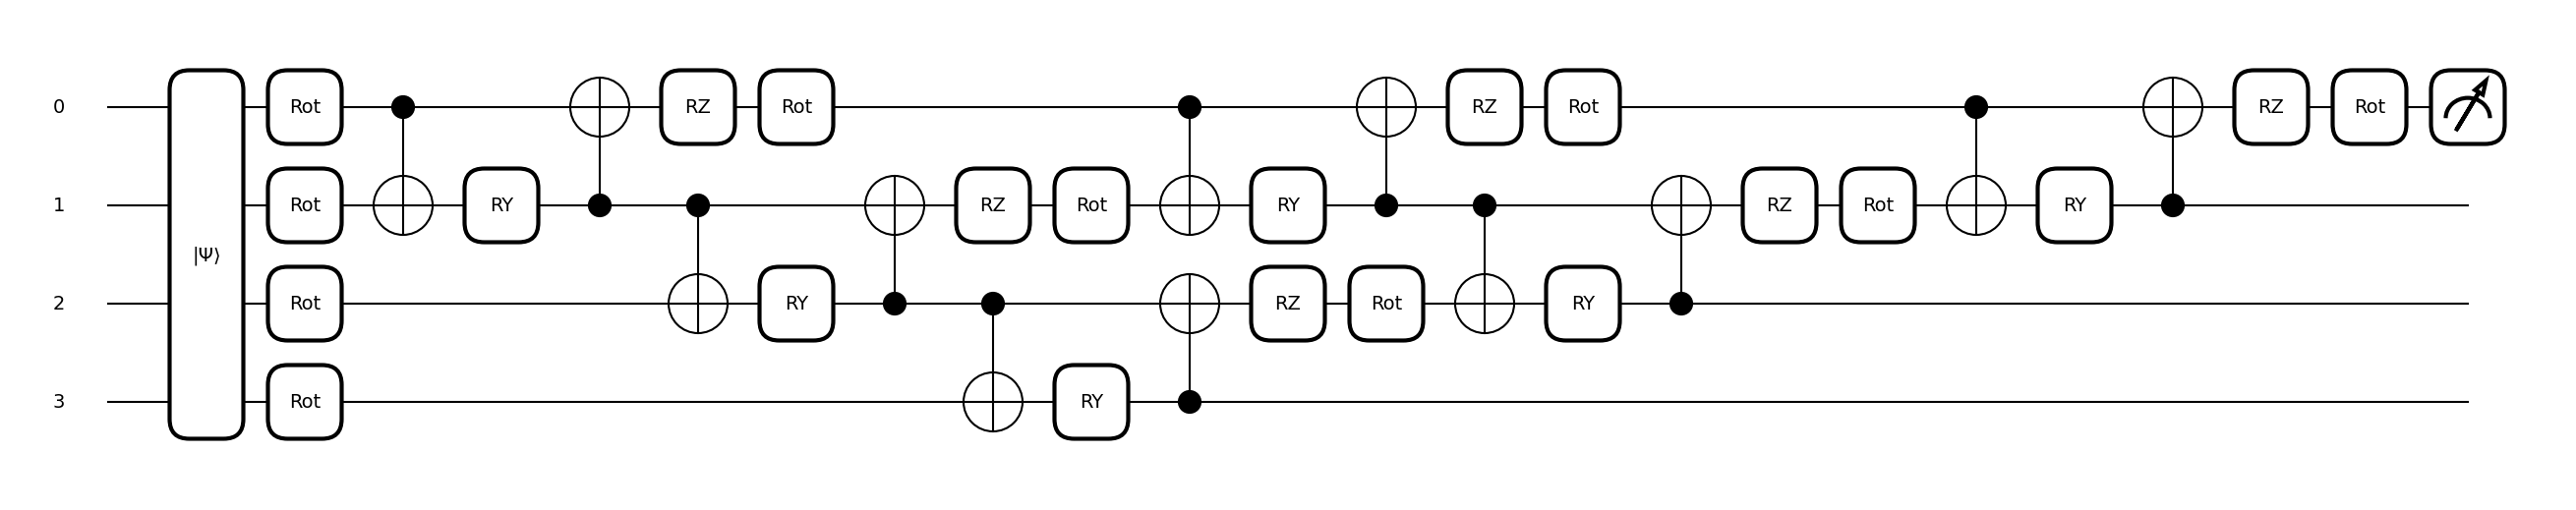

In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
from tqdm.auto import trange, tqdm 
import os
import json
import time
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import math

class CosineAnnealingScheduler:
    """Smooth cosine annealing schedule instead of manual steps."""
    def __init__(self, initial_lr=0.002, min_lr=0.0001, epochs=50, warmup_epochs=2):
        self.initial_lr = initial_lr
        self.min_lr = min_lr
        self.epochs = epochs
        self.warmup_epochs = warmup_epochs

    def get_lr(self, epoch):
        """Compute learning rate for given epoch."""
        if epoch < self.warmup_epochs:
            return self.initial_lr * (epoch + 1) / self.warmup_epochs
        progress = (epoch - self.warmup_epochs) / (self.epochs - self.warmup_epochs)
        return self.min_lr + (self.initial_lr - self.min_lr) * (1 + math.cos(math.pi * progress)) / 2

    def step(self, optimizer, epoch):
        """Update optimizer's learning rate."""
        lr = self.get_lr(epoch)
        optimizer.stepsize = lr
        return lr

# --- 1. Modular Quantum Layers ---

def get_device(config):
    """Creates a PennyLane device with GPU acceleration."""
    try:
        # This uses NVIDIA cuQuantum for massive speedups on A100/L4
        return qml.device("lightning.gpu", wires=config.n_qubits)
    except:
        # Fallback if GPU is not available
        return qml.device("lightning.qubit", wires=config.n_qubits)

def embedding_layer(features, config):
    """
    Encodes a BATCH of classical data into quantum states.
    """
    wires = range(config.n_qubits)
    
    if config.encoding_method == 'amplitude':
        # PennyLane will detect if features has a batch dimension (e.g., shape 32, 64)
        qml.AmplitudeEmbedding(features=features, wires=wires, normalize=True, pad_with=0.0)
        
    elif config.encoding_method == 'angle':
        qml.AngleEmbedding(features=features, wires=wires, rotation='Y')

    elif config.encoding_method == 'iqp':
        # IQPEmbedding: richer non-linear feature map
        qml.IQPEmbedding(
            features=features[: config.n_qubits],
            wires=wires,
            n_repeats=config.iqp_embedding_layers,          
            pattern=None          # default entangler pattern
        )

def RBS(theta, phi, wires):
    """
    Reconfigurable Beam Splitter decomposition for qubits.
    Standard pattern: RY + controlled rotations.
    """
    i, j = wires
    qml.CNOT(wires=[i, j])
    qml.RY(theta, wires=j)
    qml.CNOT(wires=[j, i])
    qml.RZ(phi, wires=i)

def hierarchical_rbs_ansatz(params, config):
    """
    ✅ FULLY IMPLEMENTED COMBINED ANSATZ
    Hierarchical depth + RBS entanglers
    
    params shape: (L, n_qubits, 3 + 2*(n_qubits-1))
    - First 3: Rot angles for each qubit (RX, RY, RZ)
    - Next 2*(n_qubits-1): RBS (theta, phi) for each edge in ring topology
    
    Hierarchically: qubit 0 gets all L layers, qubit 1 gets L-1, ..., last gets ~1
    """
    n_wires = config.n_qubits
    L = config.n_layers
    
    for l in range(L):
        # Local rotations (hierarchical: early exit per qubit)
        for w in range(n_wires):
            # Qubit w gets at most (L - w) layers
            if l > L - 1 - w:
                continue
            
            qml.Rot(
                params[l, w, 0],  # RX angle
                params[l, w, 1],  # RY angle  
                params[l, w, 2],  # RZ angle
                wires=w,
            )
        
        # Active qubits for this layer (hierarchical)
        active_wires = [w for w in range(n_wires) if l <= L - 1 - w]
        if len(active_wires) < 2:
            continue  # No entangling possible
        
        # RBS entanglers only on active qubits (ring topology)
        offset = 3  # Skip local rot params
        n_rbs_edges = len(active_wires) - 1
        
        # Extract RBS params from qubit 0's slice (broadcastable across active qubits)
        for k in range(n_rbs_edges):
            i = active_wires[k]
            j = active_wires[k + 1]
            
            # Extract RBS params from qubit i's slice
            theta = params[l, i, offset + 2*k + 0]
            phi   = params[l, i, offset + 2*k + 1]
            
            RBS(theta, phi, wires=[i, j])

def measurement_layer(meas_params, config):
    """Optional variational measurement basis."""
    for w in range(config.n_qubits):
        qml.Rot(
            meas_params[w, 0],
            meas_params[w, 1],
            meas_params[w, 2],
            wires=w,
        )

# --- 2. The QNode Builder ---

def build_qnode(config):
    dev = get_device(config)
    
    @qml.qnode(dev, interface="autograd", diff_method="adjoint", cache=True)
    def qnode(inputs, params):
        # Data embedding
        embedding_layer(inputs, config)
        
        # Ansatz (hierarchical RBS by default)
        hierarchical_rbs_ansatz(params, config)
        
        # Single readout (your original)
        return qml.expval(qml.PauliZ(0))
        
        # Multi-qubit readout (uncomment for richer features)
        # return [qml.expval(qml.PauliZ(w)) for w in range(config.n_qubits)]
        
    return qnode 

# --- 3. Training Engine ) ---
def train_quantum_model(config, X_data, y_data):
    """
    Main training loop using Autograd with TQDM progress bar.
    """
    print(f"\n⚛️ Initializing Hierarchical RBS Model ({config.n_qubits} Qubits, {config.n_layers} Layers)...")
    
    # Initialize QNode
    qnode = build_qnode(config)
   
    # ✅ CORRECTED PARAMETER SHAPE for hierarchical RBS ansatz
    n_rbs_edges = config.n_qubits - 1  # ring topology
    rbs_params_per_layer = 2 * n_rbs_edges  # theta, phi per edge
    param_shape = (
        config.n_layers, 
        config.n_qubits, 
        3 + rbs_params_per_layer
    )
    
    params = pnp.random.uniform(0, 2 * np.pi, size=param_shape, requires_grad=True) 
    print(f"⚛️ Params shape: {params.shape}")
    
    # Scheduler
    scheduler = CosineAnnealingScheduler(
        initial_lr=config.learning_rate, 
        min_lr=config.min_learning_rate, 
        epochs=config.epochs,
        warmup_epochs=config.warmup_epochs
    )

    # Data Setup
    # Note: Defined before cost_fn so global y_train works immediately if needed
    X_train, y_train_local = X_data['train'], y_data['train']
    X_val, y_val = X_data['val'], y_data['val']
    
    # Inject y_train into global scope for the cost_fn to access class weights
    global y_train 
    y_train = y_train_local

    # Cost Function (MSE)
    def cost_fn(params, x_batch, y_batch):
        # Get Predictions
        preds = qnode(x_batch, params)
        
        # Prepare Targets: Normal (0) -> -1, Pneumonia (1) -> 1
        targets = pnp.array([1 if y == 1 else -1 for y in y_batch], requires_grad=False)
        
        # Class weights (punish Normal misses more)
        # Using the global y_train set previously
        w_normal = len(y_train) / (2 * np.sum(y_train == 0))
        w_pneumonia = len(y_train) / (2 * np.sum(y_train == 1))
        
        batch_weights = pnp.array(
            [w_normal if t == -1 else w_pneumonia for t in targets], 
            requires_grad=False
        )
        
        # Weighted MSE
        squared_errors = (preds - targets) ** 2
        weighted_loss = batch_weights * squared_errors
        
        return pnp.mean(weighted_loss)

    # Tracking
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_params = None
    
    batch_size = config.batch_size
    n_batches = len(X_train) // batch_size
    
    print(f"🚀 Starting training for {config.epochs} epochs...")
    
    start_time = time.time()
    
    # Optimizer
    opt = qml.AdamOptimizer(stepsize=config.learning_rate)
    
    # ✅ TQDM WRAPPER: Use trange for the epoch loop
    pbar = trange(config.epochs, desc="Training", unit="epoch")
    dummy_input_dim = (2**config.n_qubits) if config.encoding_method == 'amplitude' else config.n_qubits
    dummy_inputs = np.random.random(dummy_input_dim)
    # We also need to match the param shape you calculated
    dummy_params = np.random.random(param_shape) 

    qml.draw_mpl(qnode)(dummy_inputs, dummy_params)
    
    for epoch in pbar:
        # Update Learning Rate
        lr = scheduler.step(opt, epoch)

        # Shuffle
        perm = np.random.permutation(len(X_train))
        X_train_shuf = X_train[perm]
        y_train_shuf = y_train_local[perm]
        
        epoch_loss = 0
        
        # Batch Loop
        for i in range(n_batches):
            batch_idx = slice(i * batch_size, (i + 1) * batch_size)
            X_batch = X_train_shuf[batch_idx]
            y_batch = y_train_shuf[batch_idx]
            
            # Step
            params, loss = opt.step_and_cost(
                lambda p: cost_fn(p, X_batch, y_batch),
                params,
            )
            epoch_loss += loss
        
        avg_train_loss = epoch_loss / n_batches
        
        # Validation
        val_loss = cost_fn(params, X_val, y_val)
        
        # Val Accuracy
        val_preds_raw = qnode(X_val, params)
        val_preds = (val_preds_raw > 0).astype(int) 
        val_acc = accuracy_score(y_val, val_preds)
        
        history['train_loss'].append(float(avg_train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)
        
        # ✅ UPDATE PROGRESS BAR: Set postfix instead of print
        pbar.set_postfix({
            "Train": f"{avg_train_loss:.4f}",
            "Val": f"{val_loss:.4f}",
            "Acc": f"{val_acc:.4f}",
            "LR": f"{lr:.1e}"
        })
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = params.copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= config.patience:
            # ✅ SAFE PRINTING: Use pbar.write to avoid breaking the bar
            pbar.write(f"⏹ Early stopping at epoch {epoch+1}")
            break
            
    train_time = time.time() - start_time
    # Final summary can be a standard print since loop is done
    print(f"✅ Training done in {train_time:.1f}s. Best Val Loss: {best_val_loss:.4f}")
    
    return best_params, qnode, history
# --- 4. Evaluation Function ---

def evaluate_model(config, params, qnode, X_test, y_test):
    print("\n📊 Evaluating on Test Set...")
    preds_raw = np.array([qnode(x, params) for x in X_test])
    
    # Map [-1, 1] -> [0, 1]
    probs = (preds_raw + 1) / 2
    preds = (probs > 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'f1_score': f1_score(y_test, preds, average='macro'),
        'auc_score': roc_auc_score(y_test, probs)
    }
    
    print(f"   Test Accuracy: {metrics['accuracy']:.2%}")
    print(f"   Test F1 Score: {metrics['f1_score']:.4f}")
    print(f"   Test AUC:      {metrics['auc_score']:.4f}")
    return metrics, preds, probs


# --- Execution ---
# 1. Train
best_params, qnode, history = train_quantum_model(CFG, X_data, y_data)

# 2. Evaluate
test_metrics, test_preds, test_probs = evaluate_model(CFG, best_params, qnode, X_data['test'], y_data['test'])

# 3. Save
results_path = os.path.join(CFG.output_dir, "quantum_results.json")
with open(results_path, 'w') as f:
    json.dump({
        'config': {k: str(v) for k, v in CFG.__dict__.items()},
        'metrics': test_metrics,
        'history': history
    }, f, indent=4)
np.save(os.path.join(CFG.output_dir, "best_params.npy"), best_params)
print(f"💾 Saved to {results_path}")


## 7 Postprocessing

In [ ]:
# ==========================================
# ⚖️ POST-PROCESSING: Threshold Optimization
# ==========================================
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the probabilities you already generated
# (Assuming 'test_probs' and 'y_data' are still in memory from the previous cell)
y_test = y_data['test']
probs = test_probs

print(f"{'Threshold':<10} | {'Acc':<8} | {'Sens.':<8} | {'Spec.':<8} | {'Balanced Acc':<12}")
print("-" * 60)

best_threshold = 0.5
best_balanced_acc = 0.0

for t in np.arange(0.5, 0.95, 0.05):
    # Apply threshold
    preds_t = (probs > t).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    acc = accuracy_score(y_test, preds_t)
    bal_acc = (sens + spec) / 2
    
    print(f"{t:.2f}       | {acc:.4f}   | {sens:.4f}   | {spec:.4f}   | {bal_acc:.4f}")
    
    if bal_acc > best_balanced_acc:
        best_balanced_acc = bal_acc
        best_threshold = t

print("-" * 60)
print(f"🏆 Best Threshold found: {best_threshold:.2f}")
print(f"   (Maximizes average of Sensitivity and Specificity)")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np
import os

# Nastavení profesionálního vzhledu grafů
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300}) # 300 DPI pro tiskovou kvalitu

def plot_training_history(history, save_dir):
    """
    Vykreslí vývoj chyby (Loss) a přesnosti (Accuracy) během tréninku.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Graf Chyby (Loss)
    ax1.plot(epochs, history['train_loss'], 'b-', label='Trénovací chyba', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r--', label='Validační chyba', linewidth=2)
    ax1.set_title('Vývoj chybové funkce (Loss)', fontweight='bold')
    ax1.set_xlabel('Epocha')
    ax1.set_ylabel('Loss (MSE)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Graf Přesnosti (Accuracy)
    ax2.plot(epochs, history['val_acc'], 'g-', label='Validační přesnost', linewidth=2)
    ax2.set_title('Vývoj přesnosti na validační sadě', fontweight='bold')
    ax2.set_xlabel('Epocha')
    ax2.set_ylabel('Přesnost (0-1)')
    ax2.set_ylim(0, 1.0)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, "training_history.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"📈 Graf tréninku uložen: {save_path}")
    plt.show()

def plot_evaluation_metrics(y_true, y_pred, y_probs, save_dir):
    """
    Vykreslí Matici záměn a ROC křivku.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Matice záměn (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'],
                annot_kws={"size": 14, "weight": "bold"})
    ax1.set_title('Matice záměn (Confusion Matrix)', fontweight='bold')
    ax1.set_ylabel('Skutečná třída')
    ax1.set_xlabel('Predikovaná třída')
    
    # 2. ROC Křivka
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC křivka (AUC = {roc_auc:.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate (1 - Specificita)')
    ax2.set_ylabel('True Positive Rate (Senzitivita)')
    ax2.set_title('ROC Křivka', fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, "evaluation_metrics.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"📊 Grafy metrik uloženy: {save_path}")
    plt.show()

# --- Spuštění vizualizace ---

# Používáme proměnné z předchozích kroků:
# history (z kroku 5)
# y_data['test'] (z kroku 4/5 - skutečné hodnoty)
# test_preds (z kroku 5 - predikované 0/1)
# test_probs (z kroku 5 - pravděpodobnosti)

print(f"=== VIZUALIZACE VÝSLEDKŮ PRO SOČ ===")
plot_training_history(history, CFG.output_dir)
plot_evaluation_metrics(y_data['test'], test_preds, test_probs, CFG.output_dir)

# Bonus: Výpis finálních čísel pro text práce
cm = confusion_matrix(y_data['test'], test_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n📝 Data pro tabulku výsledků v SOČ:")
print(f"-----------------------------------")
print(f"Počet testovacích snímků: {len(y_data['test'])}")
print(f"TP (Správně Pneumonie):   {tp}")
print(f"TN (Správně Zdraví):      {tn}")
print(f"FP (Falešný poplach):     {fp}")
print(f"FN (Přehlédnutá nemoc):   {fn}")
print(f"-----------------------------------")
print(f"Senzitivita (Recall):     {sensitivity:.4f}")
print(f"Specificita:              {specificity:.4f}")
print(f"AUC:                      {roc_auc_score(y_data['test'], test_probs):.4f}")

Kreslím s params shape: (4, 4, 9)


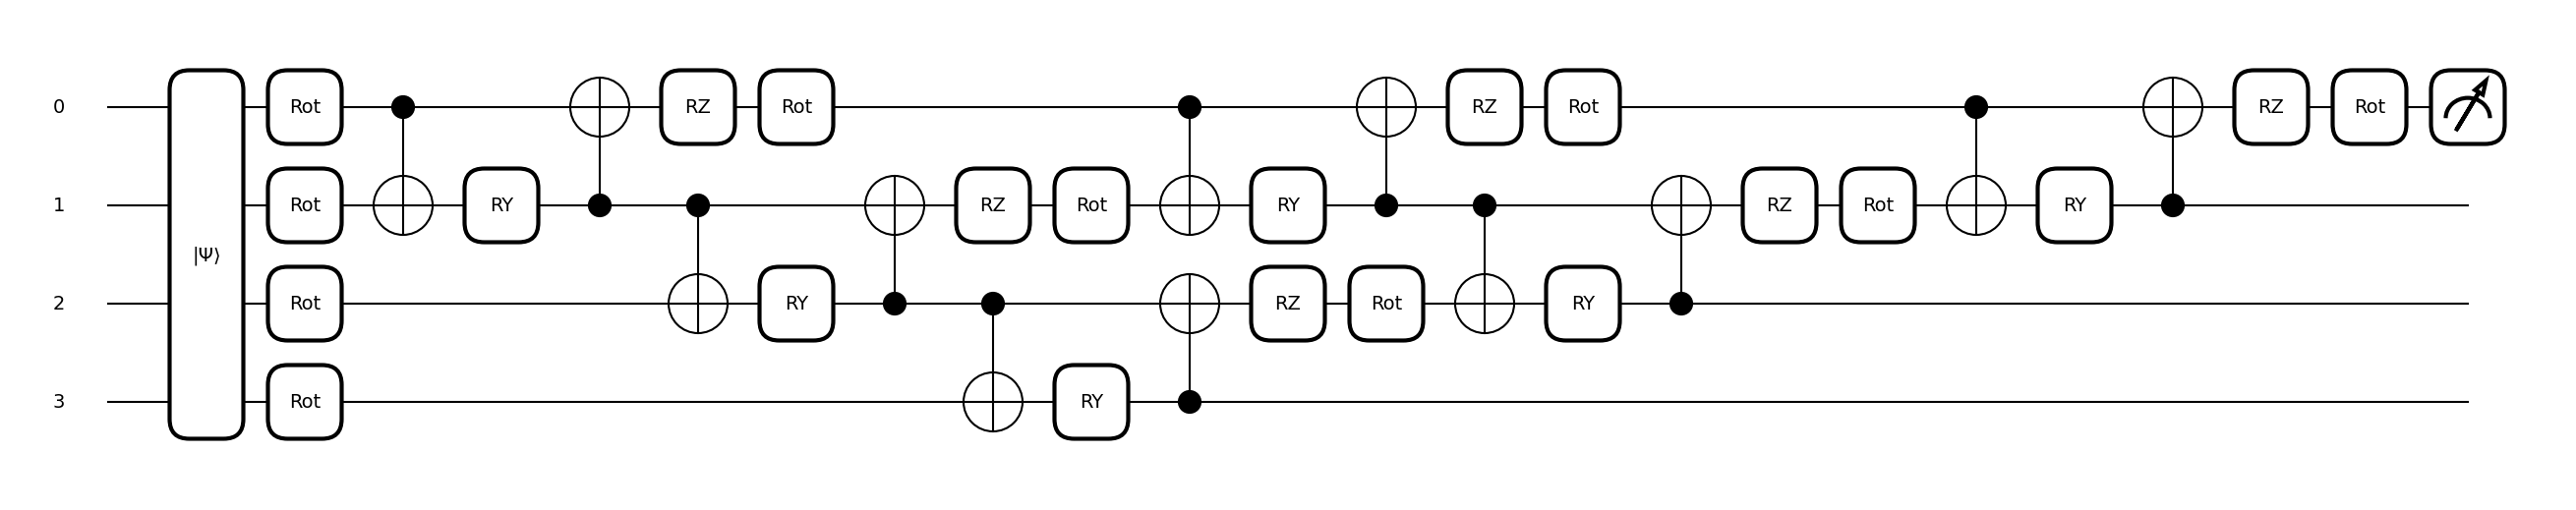

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 1. Konfigurace a QNode
config = CFG
qnode = build_qnode(config)

# 2. Výpočet správného tvaru parametrů (Param Shape)
# Tohle je stejná logika jako ve vaší funkci train_quantum_model
n_rbs_edges = config.n_qubits - 1
rbs_params_per_layer = 2 * n_rbs_edges
param_shape = (
    config.n_layers, 
    config.n_qubits, 
    3 + rbs_params_per_layer
)

# 3. Vytvoření dummy dat se SPRÁVNÝM tvarem
# Pro Input: Záleží na embeddingu. Pokud máte 'amplitude', musí to být 2^N.
dummy_input_dim = (2**config.n_qubits) if config.encoding_method == 'amplitude' else config.n_qubits
dummy_inputs = np.random.random(dummy_input_dim)

# Pro Params: Zde byla chyba. Musí to mít tvar param_shape, ne (1,)
dummy_params = np.random.random(param_shape)

# 4. Vykreslení
print(f"Kreslím s params shape: {dummy_params.shape}")
fig, ax = qml.draw_mpl(qnode)(dummy_inputs, dummy_params)
plt.show()